# Introduction to Exploritary Data Analysis
Using Pandas!

This notebook goes along with a tutorial that can be found on the [Medallion Data Science youtube channel](https://www.youtube.com/channel/UCxladMszXan-jfgzyeIMyvw). Click the link and subscribe for future tutorials.

# Step 0: Imports and Reading Data

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import scipy.stats as stats
import scipy.optimize as optimize
import scipy.spatial as spatial
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [19]:
df = pd.read_csv('data/runs/run_20260331_190615_05b7b819/whale_dataset_paper.csv')

## Step 1: Data Understanding
- Dataframe `shape`
- `head` and `tail`
- `dtypes`
- `describe`


In [20]:
df.shape

(15727, 23)

In [21]:
df.head(5)

,SIGHTINGDATE,LAT,LON,Presence,SOURCE,SOURCE_DETAIL,PACKAGE_ID,Season,SST_Celsius,Frontal_Value,Chlorophyll_mg_m3,Salinity_PSU,Water_Mass_M_WK,SST_env_source,Chlorophyll_env_source,Frontal_env_source,Salinity_env_source,SST_is_observed,Frontal_is_observed,Chlorophyll_is_observed,Salinity_is_observed,Water_Mass_is_observed,Any_env_missing
0,2002-02-06,41.93,-70.52,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1
1,2002-02-07,41.88,-70.28,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1
2,2002-02-07,42.15,-70.33,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1
3,2002-02-07,42.20,-70.20,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1
4,2002-02-07,42.24,-70.20,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1


In [22]:
df.columns

Index(['SIGHTINGDATE', 'LAT', 'LON', 'Presence', 'SOURCE', 'SOURCE_DETAIL',
       'PACKAGE_ID', 'Season', 'SST_Celsius', 'Frontal_Value',
       'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK',
       'SST_env_source', 'Chlorophyll_env_source', 'Frontal_env_source',
       'Salinity_env_source', 'SST_is_observed', 'Frontal_is_observed',
       'Chlorophyll_is_observed', 'Salinity_is_observed',
       'Water_Mass_is_observed', 'Any_env_missing'],
      dtype='str')

In [23]:
df.dtypes

SIGHTINGDATE                   str
LAT                        float64
LON                        float64
Presence                     int64
SOURCE                         str
SOURCE_DETAIL                  str
PACKAGE_ID                     str
Season                         str
SST_Celsius                float64
Frontal_Value              float64
Chlorophyll_mg_m3          float64
Salinity_PSU               float64
Water_Mass_M_WK            float64
SST_env_source                 str
Chlorophyll_env_source         str
Frontal_env_source             str
Salinity_env_source            str
SST_is_observed              int64
Frontal_is_observed          int64
Chlorophyll_is_observed      int64
Salinity_is_observed         int64
Water_Mass_is_observed       int64
Any_env_missing              int64
dtype: object

In [24]:
df.describe()

,LAT,LON,Presence,SST_Celsius,Frontal_Value,Chlorophyll_mg_m3,Salinity_PSU,Water_Mass_M_WK,SST_is_observed,Frontal_is_observed,Chlorophyll_is_observed,Salinity_is_observed,Water_Mass_is_observed,Any_env_missing
count,15727.000000,15727.000000,15727.000000,15538.000000,15504.000000,15465.000000,4075.000000,15520.000000,15727.000000,15727.000000,15727.000000,15727.000000,15727.000000,15727.000000
mean,38.801135,-73.050261,0.793985,11.863411,0.347175,3.346519,34.478226,174.146203,0.987982,0.985821,0.983341,0.259109,0.986838,0.741845
std,5.763020,5.465041,0.404454,6.853581,0.798907,4.885775,2.088608,112.186741,0.108967,0.118234,0.127995,0.438159,0.113972,0.437633
min,24.433130,-85.770000,0.000000,-160.845000,0.000000,0.034057,27.215614,38.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.396417,-80.890400,1.000000,6.598448,0.000000,0.940829,32.997517,66.171429,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000
50%,41.910000,-70.310000,1.000000,11.583782,0.121638,1.902502,34.416970,184.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,42.255517,-70.160000,1.000000,16.189432,0.385787,3.860885,36.084677,248.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,51.690000,-52.680000,1.000000,163.834990,26.145123,99.770515,39.988754,458.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Step 2: Data Preperation
- Dropping irrelevant columns and rows
- Identifying duplicated columns
- Renaming Columns
- Feature Creation

In [8]:
# Example of dropping columns
# df.drop(['Opening date'], axis=1)

In [25]:
df = df[['SIGHTINGDATE', 'LAT', 'LON', 'Presence', 
         # 'SOURCE', 'SOURCE_DETAIL', 'PACKAGE_ID', 
         'Season', 'SST_Celsius', 'Frontal_Value',
       'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK',
       'SST_env_source', 'Chlorophyll_env_source', 'Frontal_env_source', 'Salinity_env_source', 
       'SST_is_observed', 'Frontal_is_observed', 'Chlorophyll_is_observed', 'Salinity_is_observed',
       'Water_Mass_is_observed', 'Any_env_missing']].copy()

In [27]:
df['SIGHTINGDATE'] = pd.to_datetime(df['SIGHTINGDATE'])

In [ ]:
# Rename our columns
# df = df.rename(columns={'coaster_name':'Coaster_Name',
#                    'year_introduced':'Year_Introduced',
#                    'opening_date_clean':'Opening_Date',
#                    'speed_mph':'Speed_mph',
#                    'height_ft':'Height_ft',
#                    'Inversions_clean':'Inversions',
#                    'Gforce_clean':'Gforce'})

In [28]:
df.isna().sum()

SIGHTINGDATE                   0
LAT                            0
LON                            0
Presence                       0
Season                         0
SST_Celsius                  189
Frontal_Value                223
Chlorophyll_mg_m3            262
Salinity_PSU               11652
Water_Mass_M_WK              207
SST_env_source               189
Chlorophyll_env_source       262
Frontal_env_source           223
Salinity_env_source        11652
SST_is_observed                0
Frontal_is_observed            0
Chlorophyll_is_observed        0
Salinity_is_observed           0
Water_Mass_is_observed         0
Any_env_missing                0
dtype: int64

In [30]:
# df.loc[df.duplicated()]

In [ ]:
# Check for duplicate coaster name
# df.loc[df.duplicated(subset=['Coaster_Name'])].head(5)

In [ ]:
# Checking an example duplicate
# df.query('Coaster_Name == "Crystal Beach Cyclone"')

In [31]:
df.columns

Index(['SIGHTINGDATE', 'LAT', 'LON', 'Presence', 'Season', 'SST_Celsius',
       'Frontal_Value', 'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK',
       'SST_env_source', 'Chlorophyll_env_source', 'Frontal_env_source',
       'Salinity_env_source', 'SST_is_observed', 'Frontal_is_observed',
       'Chlorophyll_is_observed', 'Salinity_is_observed',
       'Water_Mass_is_observed', 'Any_env_missing'],
      dtype='str')

In [15]:
# df = df.loc[~df.duplicated(subset=['DATE_KEY', 'LAT_KEY', 'LON_KEY', 'SST_Celsius', 'Frontal_Value',
#        'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK'])] \
#     .reset_index(drop=True).copy()

# Step 3: Feature Understanding
(Univariate analysis)

- Plotting Feature Distributions
    - Histogram
    - KDE
    - Boxplot

In [ ]:
# df['Year_Introduced'].value_counts()

In [ ]:
# ax = df['Year_Introduced'].value_counts() \
#     .head(10) \
#     .plot(kind='bar', title='Top 10 Years Coasters Introduced')
# ax.set_xlabel('Year Introduced')
# ax.set_ylabel('Count')

After outlier removal: 2386 rows remaining


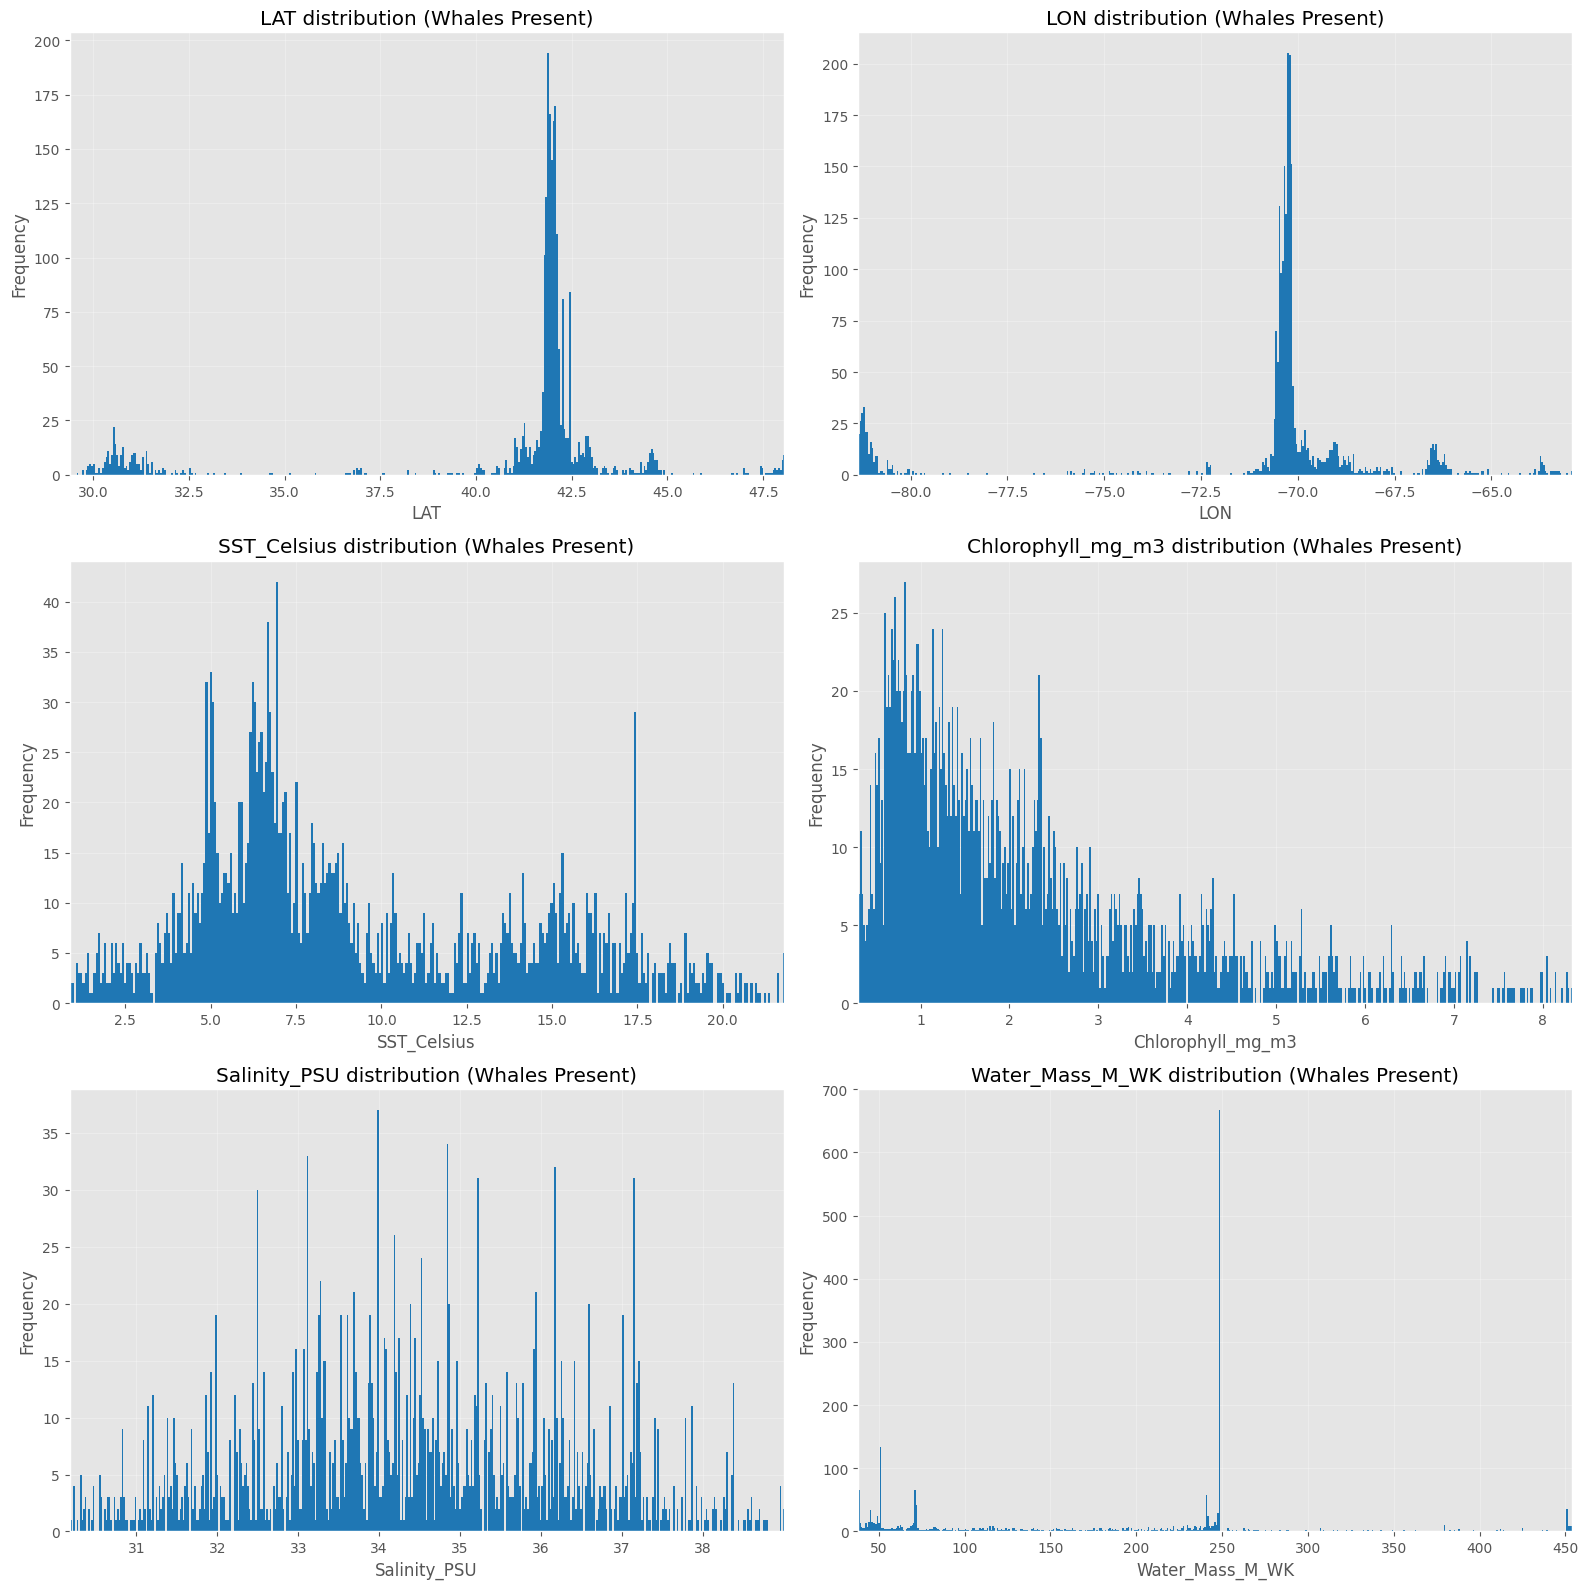

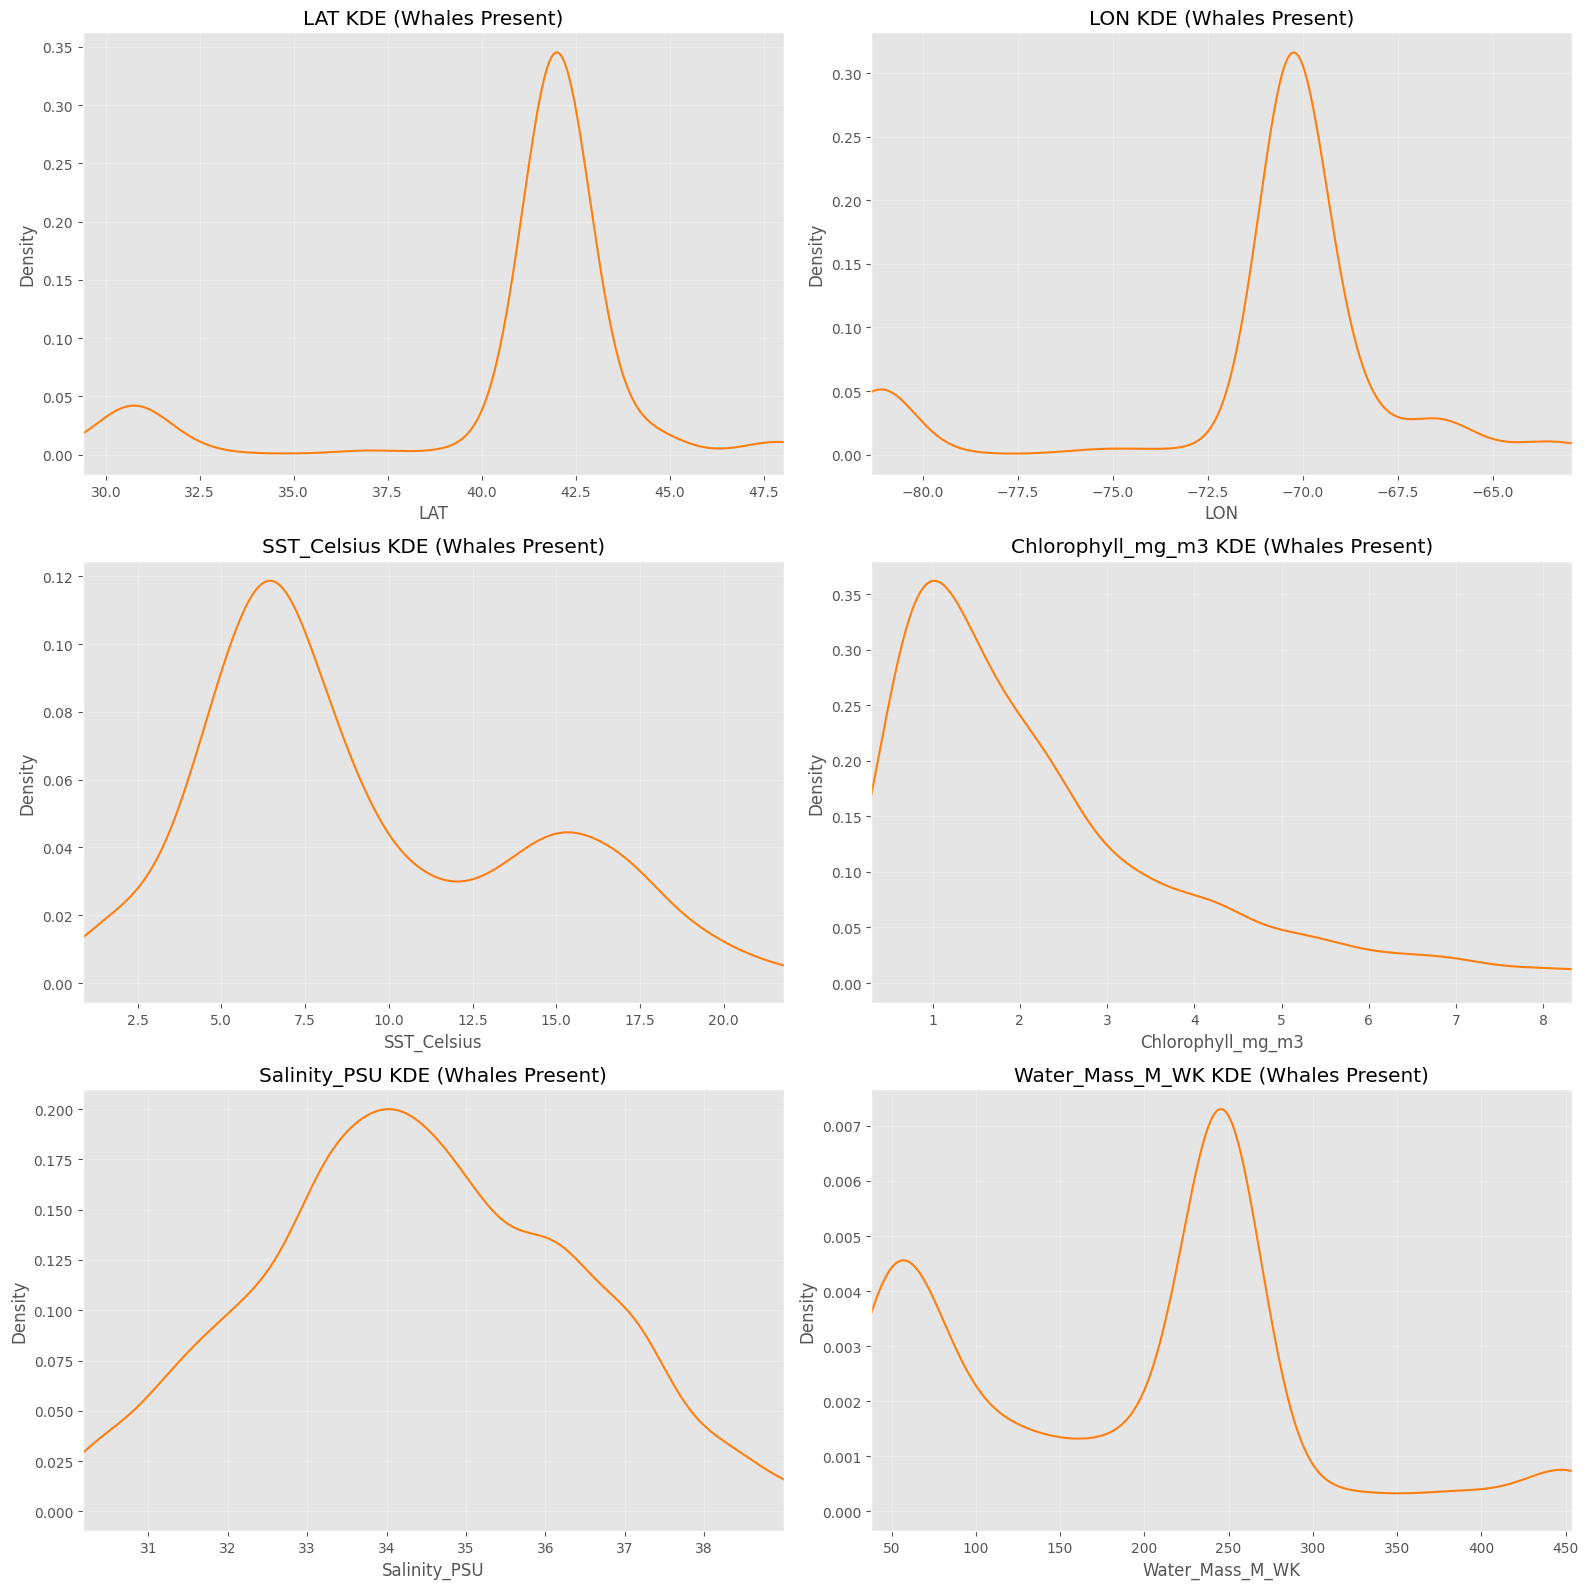

In [49]:
numeric_cols = [
    'LAT', 'LON', 'SST_Celsius',
    'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK'
]

# Filter for whale presence
df_whales = df[df['Presence'] == 1].copy()

# Remove outliers using IQR method
for col in numeric_cols:
    Q1 = df_whales[col].quantile(0.25)
    Q3 = df_whales[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_whales = df_whales[(df_whales[col] >= lower_bound) & (df_whales[col] <= upper_bound)]

print(f"After outlier removal: {len(df_whales)} rows remaining")

# Histograms for numeric features with smaller bin width
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
for ax, col in zip(axes.flatten(), numeric_cols):
    series = df_whales[col].dropna()
    x_min, x_max = series.quantile([0.01, 0.99])
    series.plot(kind='hist', bins=500, ax=ax, title=f'{col} distribution (Whales Present)', color='#1f77b4')
    ax.set_xlabel(col)
    ax.set_xlim(x_min, x_max)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# KDE plots for numeric features
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
for ax, col in zip(axes.flatten(), numeric_cols):
    series = df_whales[col].dropna()
    x_min, x_max = series.quantile([0.01, 0.99])
    series.plot(kind='kde', ax=ax, title=f'{col} KDE (Whales Present)', color='#ff7f0e')
    ax.set_xlabel(col)
    ax.set_xlim(x_min, x_max)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Step 4: Feature Relationships
- LAT vs LON: Geographic distribution of whale sightings
- SST vs Chlorophyll: Ecological prey-productivity relationship
- SST vs Salinity: Water mass characteristics affecting habitat

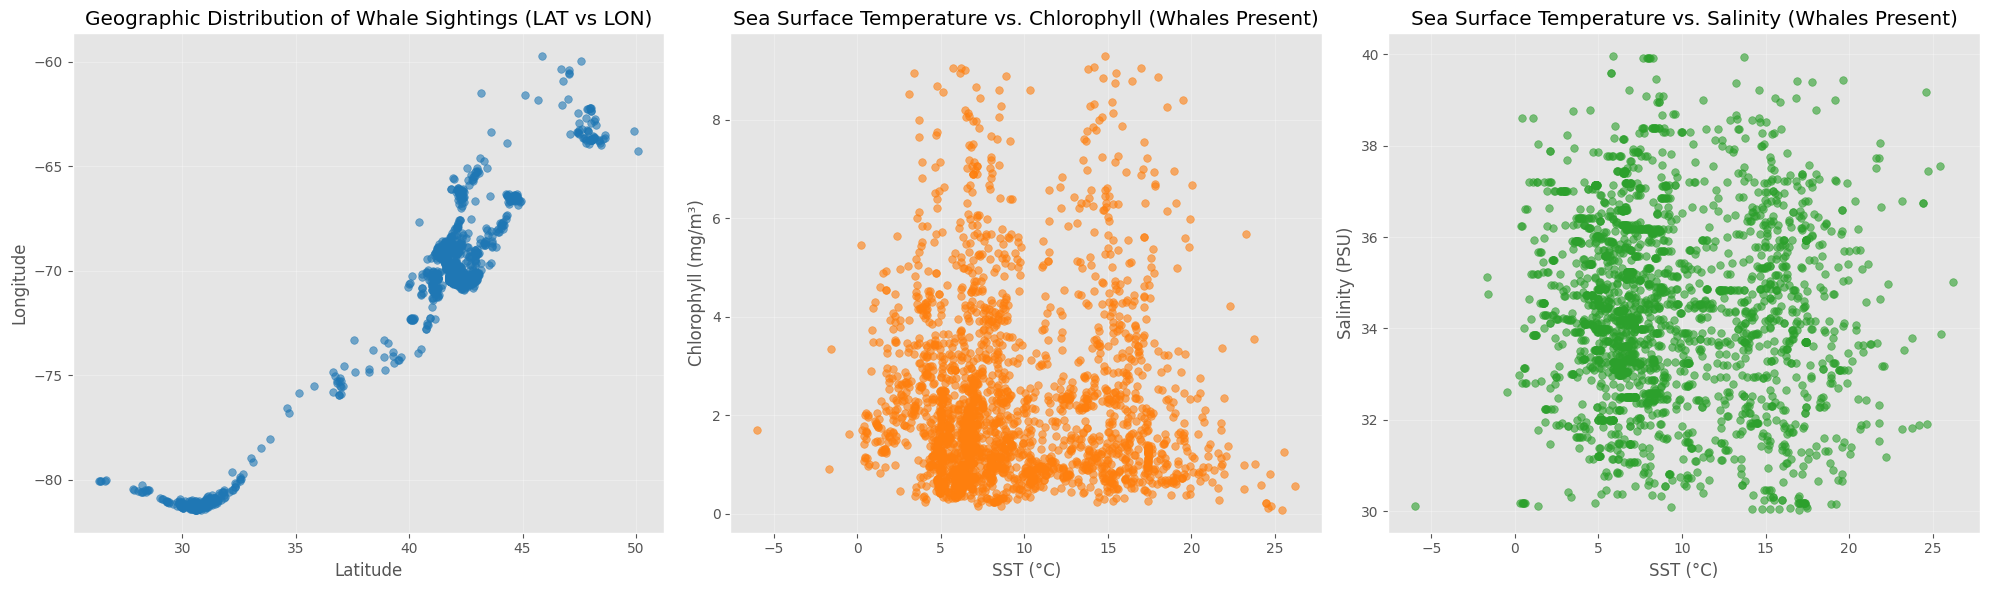

In [64]:
# All three scatter plots in one cell
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Geographic distribution (LAT vs LON)
axes[0].scatter(df_whales['LAT'], df_whales['LON'], alpha=0.6, s=30, color='#1f77b4')
axes[0].set_xlabel('Latitude')
axes[0].set_ylabel('Longitude')
axes[0].set_title('Geographic Distribution of Whale Sightings (LAT vs LON)')
axes[0].grid(alpha=0.3)

# 2. SST vs Chlorophyll relationship
series2 = df_whales[['SST_Celsius', 'Chlorophyll_mg_m3']].dropna()
axes[1].scatter(series2['SST_Celsius'], series2['Chlorophyll_mg_m3'], alpha=0.6, s=30, color='#ff7f0e')
axes[1].set_xlabel('SST (°C)')
axes[1].set_ylabel('Chlorophyll (mg/m³)')
axes[1].set_title('Sea Surface Temperature vs. Chlorophyll (Whales Present)')
axes[1].grid(alpha=0.3)

# 3. SST vs Salinity relationship
series3 = df_whales[['SST_Celsius', 'Salinity_PSU']].dropna()
axes[2].scatter(series3['SST_Celsius'], series3['Salinity_PSU'], alpha=0.6, s=30, color='#2ca02c')
axes[2].set_xlabel('SST (°C)')
axes[2].set_ylabel('Salinity (PSU)')
axes[2].set_title('Sea Surface Temperature vs. Salinity (Whales Present)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
df_corr = df_whales[['SST_Celsius','Chlorophyll_mg_m3', 
              'Salinity_PSU', 'Water_Mass_M_WK']].dropna().corr()
df_corr

,SST_Celsius,Chlorophyll_mg_m3,Salinity_PSU,Water_Mass_M_WK
SST_Celsius,1.000000,0.012835,-0.050393,-0.259908
Chlorophyll_mg_m3,0.012835,1.000000,0.127645,-0.077798
Salinity_PSU,-0.050393,0.127645,1.000000,0.043334
Water_Mass_M_WK,-0.259908,-0.077798,0.043334,1.000000


<Axes: >

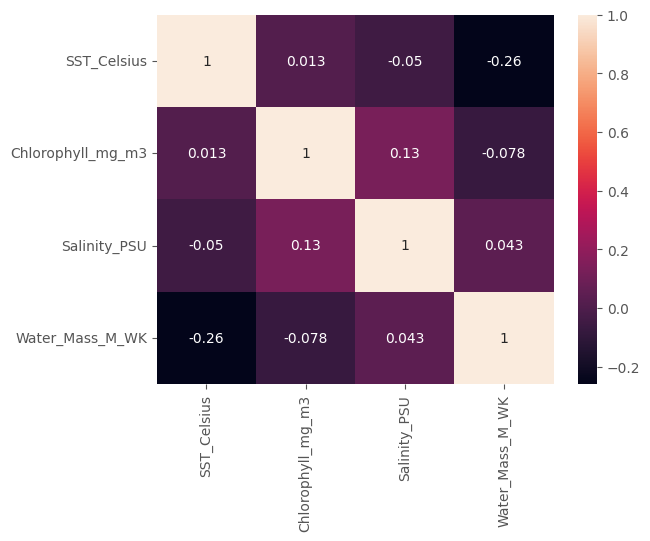

In [60]:
sns.heatmap(df_corr, annot=True)

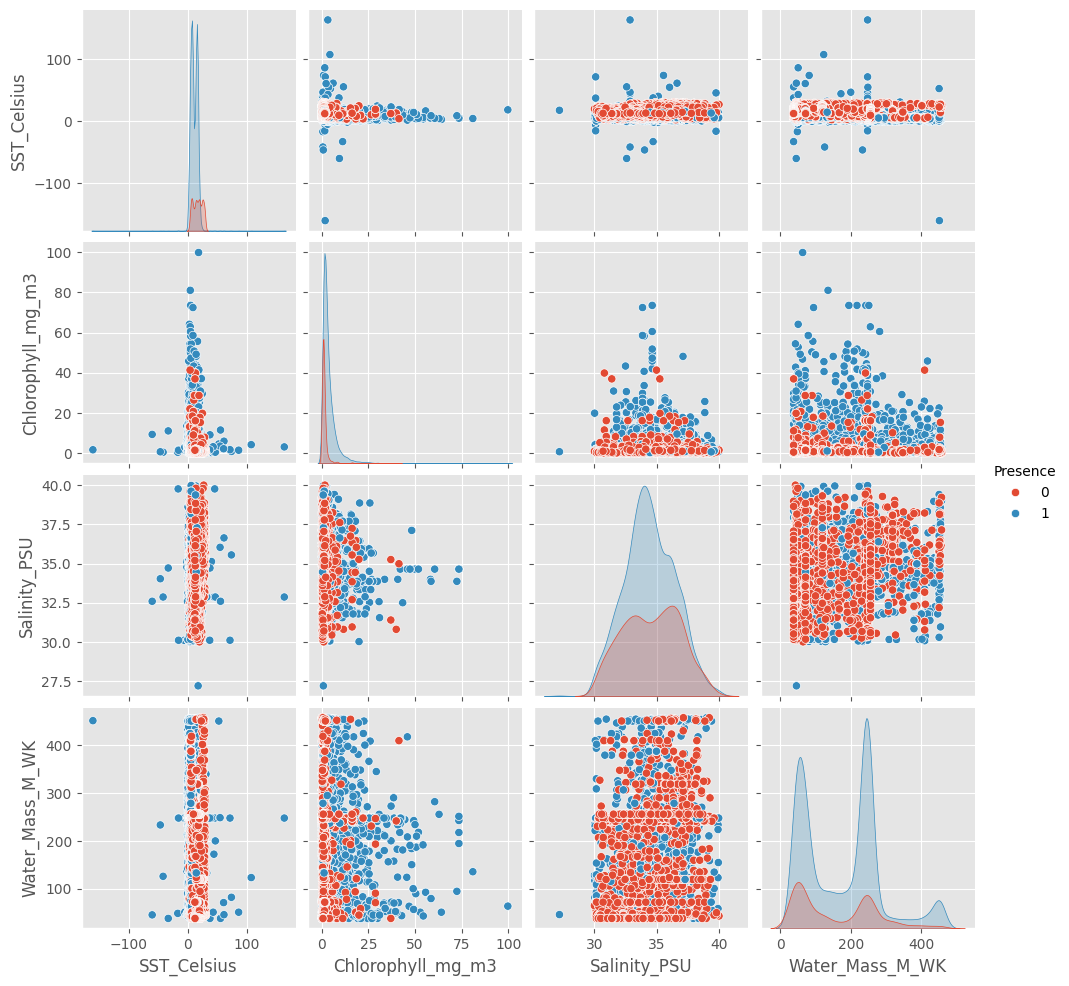

In [ ]:
sns.pairplot(df,
             vars=['SST_Celsius', 'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK'],
            hue='Presence')
plt.show()

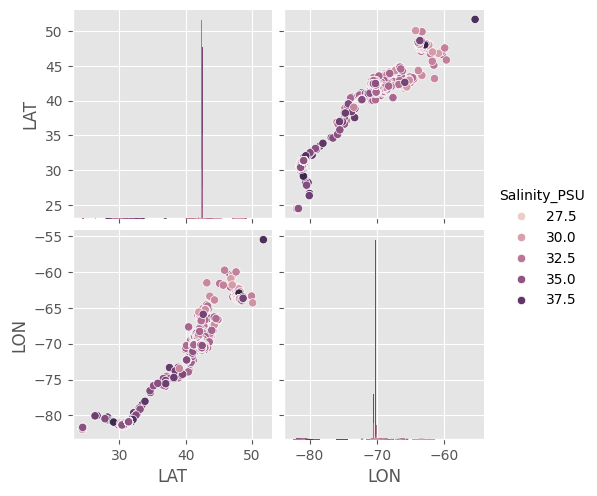

In [69]:
sns.pairplot(df,
             vars=['LAT', 'LON'],
            hue='Salinity_PSU')
plt.show()

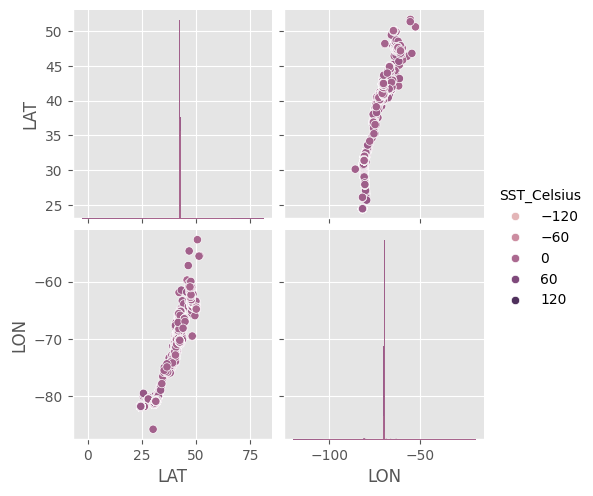

In [68]:
sns.pairplot(df,
             vars=['LAT', 'LON'],
            hue='SST_Celsius')
plt.show()

# Step 5: Forecasting-Focused Analysis
Key questions for whale presence prediction:
- How does whale presence vary by season?
- What is the temporal trend? (increasing/decreasing sightings?)
- Which months have highest whale presence?
- Do environmental conditions differ during whale presence vs. absence?

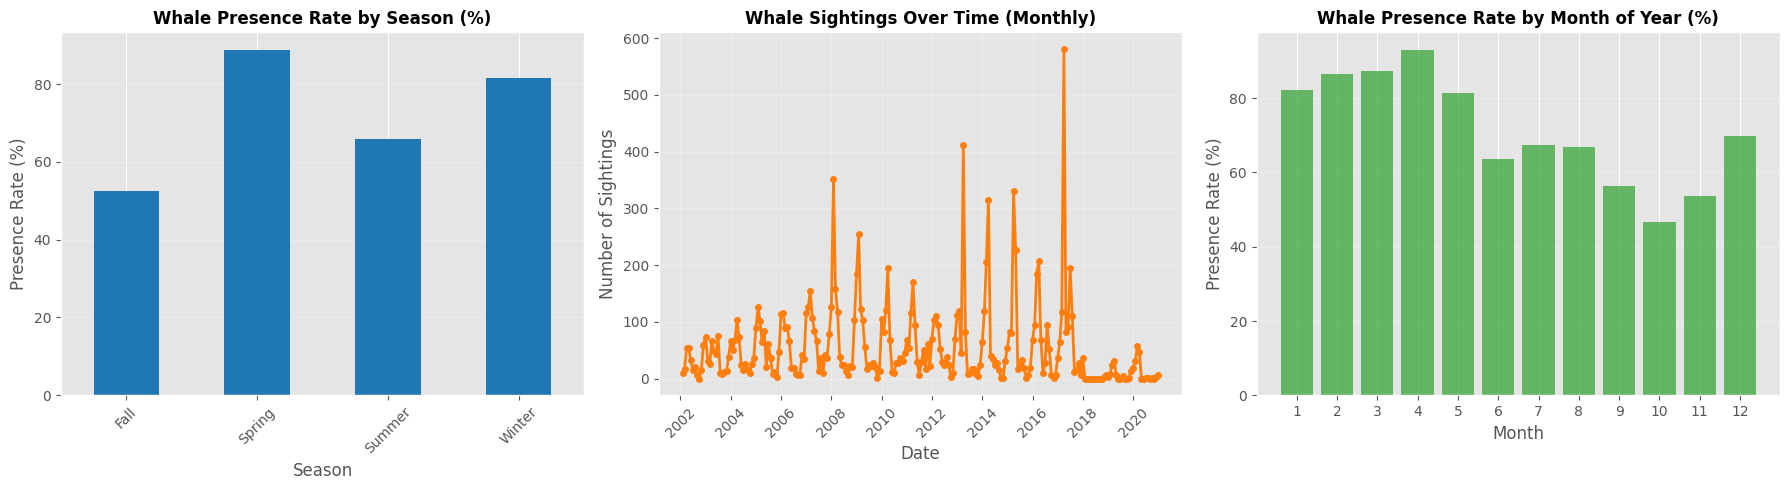


FORECASTING-RELEVANT INSIGHTS

Seasonal Presence Rates:
  Fall: 52.51%
  Spring: 88.85%
  Summer: 66.00%
  Winter: 81.61%


In [58]:
# Create forecasting-focused EDA visualizations
fig = plt.figure(figsize=(18, 5))

# 1. Presence by Season
ax1 = plt.subplot(1, 3, 1)
season_presence = df.groupby('Season')['Presence'].agg(['sum', 'count'])
season_presence['presence_rate'] = season_presence['sum'] / season_presence['count'] * 100
season_presence['presence_rate'].plot(kind='bar', ax=ax1, color='#1f77b4')
ax1.set_title('Whale Presence Rate by Season (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Season')
ax1.set_ylabel('Presence Rate (%)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.grid(alpha=0.3, axis='y')

# 2. Temporal Trend - Sightings over time
ax2 = plt.subplot(1, 3, 2)
df_time = df[df['Presence'] == 1].set_index('SIGHTINGDATE').resample('MS').size()
ax2.plot(df_time.index, df_time.values, linewidth=2, color='#ff7f0e', marker='o', markersize=4)
ax2.set_title('Whale Sightings Over Time (Monthly)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Number of Sightings')
ax2.grid(alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# 3. Presence by Month
ax3 = plt.subplot(1, 3, 3)
df['Month'] = df['SIGHTINGDATE'].dt.month
month_presence = df.groupby('Month')['Presence'].agg(['sum', 'count'])
month_presence['presence_rate'] = month_presence['sum'] / month_presence['count'] * 100
ax3.bar(month_presence.index, month_presence['presence_rate'], color='#2ca02c', alpha=0.7)
ax3.set_title('Whale Presence Rate by Month of Year (%)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Presence Rate (%)')
ax3.set_xticks(range(1, 13))
ax3.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
class_counts = df['Presence'].value_counts()
print("\n" + "="*70)
print("FORECASTING-RELEVANT INSIGHTS")
print("="*70)
print(f"\nSeasonal Presence Rates:")
for season in season_presence.index:
    print(f"  {season}: {season_presence.loc[season, 'presence_rate']:.2f}%")